In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.datasets import IMDB
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence


OSError: /home2/liyang/micromamba/envs/fl310/lib/python3.10/site-packages/torchtext/lib/libtorchtext.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs

In [ ]:
# Tokenizer
tokenizer = get_tokenizer("basic_english")

# Function to yield tokens from dataset
def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

# Build vocabulary from IMDB training dataset
train_iter = IMDB(split='train')
vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<PAD>", "<UNK>"])
vocab.set_default_index(vocab["<UNK>"])  # Handle unknown words

# Convert text to tensor
def text_pipeline(text):
    return vocab(tokenizer(text))

# Label conversion
label_pipeline = lambda x: 1 if x == "pos" else 0


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, split):
        self.data = list(IMDB(split=split))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label, text = self.data[idx]
        return torch.tensor(label_pipeline(label)), torch.tensor(text_pipeline(text))

# Collate function for padding
def collate_batch(batch):
    labels, texts = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.long)
    texts = pad_sequence(texts, padding_value=vocab["<PAD>"], batch_first=True)
    return labels, texts

# DataLoaders
batch_size = 32
train_dataset = IMDBDataset(split='train')
test_dataset = IMDBDataset(split='test')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_batch)


In [ ]:
class DNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(DNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab["<PAD>"])
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, text):
        embedded = self.embedding(text).mean(dim=1)  # Average embeddings over sequence
        x = self.fc1(embedded)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return self.softmax(x)

# Model parameters
vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 256
output_dim = 2  # Binary classification

model = DNNClassifier(vocab_size, embed_dim, hidden_dim, output_dim)


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for labels, texts in train_loader:
        labels, texts = labels.to(device), texts.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")


In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for labels, texts in test_loader:
        labels, texts = labels.to(device), texts.to(device)
        outputs = model(texts)
        _, preds = torch.max(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}")


In [2]:
import numpy as np
from skopt import Optimizer
from skopt.space import Real

# Simulated function: d_next depends on d and lambda
# You should replace this with your real function
def simulate_d(d, lambd):
    return d + (2 * lambd - 1) * np.abs(np.sin(d))  # Example dynamics

# Define search space (lambda in [0,1])
space = [Real(0.0, 1.0, name='lambda')]

# Initialize Bayesian Optimizer
optimizer = Optimizer(space, random_state=42)

d_current = 1.0  # Initial d value

# Run iterative optimization for multiple steps
for _ in range(30):
    lambd = optimizer.ask()[0]  # Suggest next lambda
    d_next = simulate_d(d_current, lambd)  # Get new d
    optimizer.tell([lambd], -d_next)  # Update optimizer
    d_current = d_next  # Update d
    print(f"Iteration: {_+1}, Lambda: {lambd:.4f}, d: {d_current:.4f}")

# Best lambda found
best_lambda = optimizer.Xi[np.argmin(optimizer.yi)][0]
print(f"Best lambda found: {best_lambda}")


Iteration: 1, Lambda: 0.7965, d: 1.4991
Iteration: 2, Lambda: 0.1834, d: 0.8676
Iteration: 3, Lambda: 0.7797, d: 1.2942
Iteration: 4, Lambda: 0.5969, d: 1.4806
Iteration: 5, Lambda: 0.4458, d: 1.3727
Iteration: 6, Lambda: 0.1000, d: 0.5883
Iteration: 7, Lambda: 0.4592, d: 0.5431
Iteration: 8, Lambda: 0.3337, d: 0.3712
Iteration: 9, Lambda: 0.1429, d: 0.1121
Iteration: 10, Lambda: 0.6509, d: 0.1459
Iteration: 11, Lambda: 0.7978, d: 0.2324
Iteration: 12, Lambda: 0.5946, d: 0.2760
Iteration: 13, Lambda: 0.7811, d: 0.4292
Iteration: 14, Lambda: 0.4390, d: 0.3785
Iteration: 15, Lambda: 0.7907, d: 0.5933
Iteration: 16, Lambda: 0.6098, d: 0.7160
Iteration: 17, Lambda: 0.4472, d: 0.6467
Iteration: 18, Lambda: 0.7649, d: 0.9660
Iteration: 19, Lambda: 0.7411, d: 1.3627
Iteration: 20, Lambda: 0.7225, d: 1.7981
Iteration: 21, Lambda: 0.7136, d: 2.2143
Iteration: 22, Lambda: 0.7168, d: 2.5611
Iteration: 23, Lambda: 0.7100, d: 2.7915
Iteration: 24, Lambda: 0.7010, d: 2.9294
Iteration: 25, Lambda: 0.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# Define the Q-network (Neural Network)
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_dim)  # Output layer for action value

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Define the DQN Agent
class DQNAgent:
    def __init__(self, input_dim, output_dim, gamma=0.99, epsilon=0.1, lr=0.001, batch_size=64, buffer_size=10000):
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration factor
        self.batch_size = batch_size
        self.memory = deque(maxlen=buffer_size)  # Replay buffer
        self.q_network = QNetwork(input_dim, output_dim).float()
        self.target_network = QNetwork(input_dim, output_dim).float()
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

        # Sync target network with Q-network initially
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

    def act(self, state):
        # Exploration vs exploitation
        if random.random() < self.epsilon:
            return np.random.uniform(0, 1)  # Random action (lambda in [0, 1])
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.q_network(state_tensor)
            action = torch.argmax(q_values).item()
            return action / 100  # scale back to [0, 1]

    def store_experience(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample_batch(self):
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (torch.tensor(states, dtype=torch.float32),
                torch.tensor(actions, dtype=torch.float32),
                torch.tensor(rewards, dtype=torch.float32),
                torch.tensor(next_states, dtype=torch.float32),
                torch.tensor(dones, dtype=torch.bool))

    def train(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.sample_batch()

        # Get Q values for current state-action pair
        q_values = self.q_network(states)
        q_value = q_values.gather(1, actions.unsqueeze(1).long())

        # Get target Q values from the target network
        next_q_values = self.target_network(next_states)
        next_q_value = next_q_values.max(1)[0]
        target = rewards + (1 - dones.float()) * self.gamma * next_q_value


        # Calculate loss and perform backpropagation
        loss = nn.MSELoss()(q_value.squeeze(1), target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update the target network
        self.target_network.load_state_dict(self.q_network.state_dict())

    def update_epsilon(self, decay=0.995, min_epsilon=0.01):
        self.epsilon = max(min_epsilon, self.epsilon * decay)

# Environment interaction (You would need to define this)
def environment_step(state, action):
    # Modify this function to work with your environment
    # The state contains (s, m, b, accuracy)
    # Action is the lambda value
    # You will return the next state, reward, and done (True if episode ends)
    # For now, this is a placeholder
    next_state = state  # Update based on your model
    reward = -np.abs(state[3] - state[3] + action)  # Placeholder reward function
    done = False  # Placeholder termination condition
    return next_state, reward, done

# Training loop
def train_dqn_agent():
    agent = DQNAgent(input_dim=4, output_dim=100)  # 4 input values (s, m, b, accuracy), output 100 (discretized lambda)
    num_episodes = 1000
    for episode in range(num_episodes):
        state = np.random.rand(4)  # Initialize a random state (s, m, b, accuracy)
        done = False
        total_reward = 0
        while not done:
            action = agent.act(state)
            next_state, reward, done = environment_step(state, action)
            agent.store_experience(state, action, reward, next_state, done)
            agent.train()
            state = next_state
            total_reward += reward

        agent.update_epsilon()

        if episode % 10 == 0:
            print(f"Episode {episode}, Total Reward: {total_reward}, Epsilon: {agent.epsilon}")

# Call this to start training
train_dqn_agent()


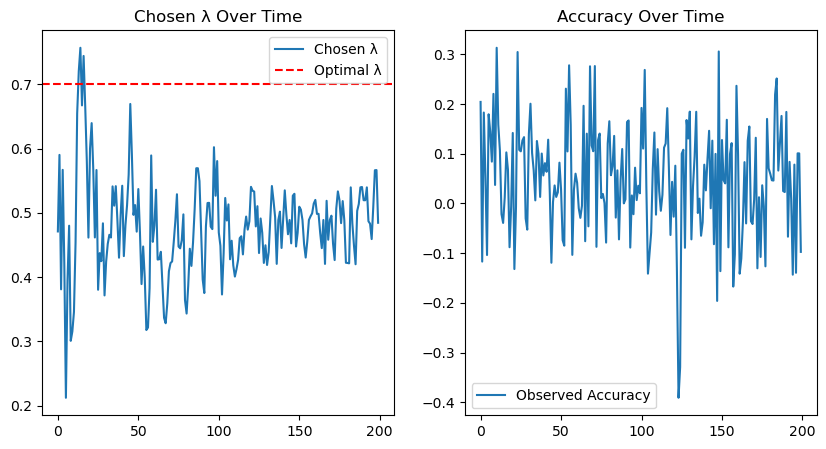

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class AttackThompsonSampling:
    def __init__(self, alpha=1, beta=1, window_size=50, momentum=0.5, min_step=0.01):
        self.alpha = alpha          # Beta prior (α)
        self.beta = beta            # Beta prior (β)
        self.window_size = window_size  
        self.momentum = momentum    # 0.9 = stronger memory
        self.min_step = min_step
        self.lambda_history = []    # Track chosen lambdas
        self.accuracy_history = []  # Track observed accuracies (lower = better)
        self.ema_lambda = 0.5       # Exponential moving average of λ
        self.pending_lambda = None   # λ waiting for accuracy feedback

    def choose_lambda(self):
        # Sample from Beta distribution
        raw_lambda = np.random.beta(self.alpha, self.beta)
        
        # Apply momentum toward historically bad λ's
        smoothed_lambda = self.momentum * self.ema_lambda + (1 - self.momentum) * raw_lambda
        
        # Enforce minimum exploration
        if len(self.lambda_history) > 0:
            prev_worst = self.lambda_history[np.argmin(self.accuracy_history)]  # λ with lowest accuracy
            if abs(smoothed_lambda - prev_worst) < self.min_step:
                smoothed_lambda = prev_worst + np.sign(smoothed_lambda - prev_worst) * self.min_step
        
        self.pending_lambda = np.clip(smoothed_lambda, 0, 1)
        self.ema_lambda = smoothed_lambda
        return self.pending_lambda

    def update(self, accuracy_t):
        self.lambda_history.append(self.pending_lambda)
        self.accuracy_history.append(accuracy_t)
        
        # Maintain sliding window
        if len(self.accuracy_history) > self.window_size:
            self.lambda_history.pop(0)
            self.accuracy_history.pop(0)
        
        # Update Beta to favor λ's that minimize accuracy
        windowed_acc = self.accuracy_history[-self.window_size:]
        worst_acc = np.min(windowed_acc)
        normalized_harm = (worst_acc - accuracy_t) / (worst_acc - np.max(windowed_acc) + 1e-6)  # How much worse this λ is
        
        self.alpha += 0.3 * normalized_harm  # Smaller, stable updates
        self.beta += 0.3 * (1 - normalized_harm)
        
# Define a test function where accuracy is a function of lambda
def test_function(lambda_value):
    return (lambda_value - 0.7) ** 2 + 0.1 * np.random.randn()  # Quadratic + noise

# Initialize the attack model
attack = AttackThompsonSampling()

# Run the test
num_iterations = 200
lambda_values = []
accuracy_values = []

for _ in range(num_iterations):
    chosen_lambda = attack.choose_lambda()
    accuracy = test_function(chosen_lambda)
    attack.update(accuracy)
    
    lambda_values.append(chosen_lambda)
    accuracy_values.append(accuracy)

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(lambda_values, label="Chosen λ")
plt.axhline(0.7, color='r', linestyle='--', label="Optimal λ")
plt.legend()
plt.title("Chosen λ Over Time")

plt.subplot(1, 2, 2)
plt.plot(accuracy_values, label="Observed Accuracy")
plt.legend()
plt.title("Accuracy Over Time")

plt.show()


/home2/liyang/micromamba/envs/fl39/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Step 0: lambda = 0.000, accuracy = 0.005
Step 1: lambda = 0.232, accuracy = 0.679
Step 2: lambda = 0.273, accuracy = 0.336
Step 3: lambda = 0.394, accuracy = -0.672
Step 4: lambda = 0.192, accuracy = 0.964
Step 5: lambda = 0.141, accuracy = 1.194
Step 6: lambda = 0.111, accuracy = 1.096
Step 7: lambda = 1.000, accuracy = -0.412
Step 8: lambda = 0.101, accuracy = 1.077
Step 9: lambda = 0.697, accuracy = 0.624
Step 10: lambda = 0.788, accuracy = 1.139
Step 11: lambda = 0.838, accuracy = 1.032
Step 12: lambda = 0.808, accuracy = 1.162
Step 13: lambda = 0.869, accuracy = 0.838
Step 14: lambda = 0.768, accuracy = 1.007
Step 15: lambda = 0.596, accuracy = -0.156
Step 16: lambda = 0.778, accuracy = 1.112
Step 17: lambda = 0.758, accuracy = 1.017
Step 18: lambda = 0.747, accuracy = 1.137
Step 19: lambda = 0.737, accuracy = 0.992
Step 20: lambda = 0.737, accuracy = 1.121
Step 21: lambda = 0.727, accuracy = 1.164
Step 22: lambda = 0.717, accuracy = 1.054
Step 23: lambda = 0.707, accuracy = 1.090

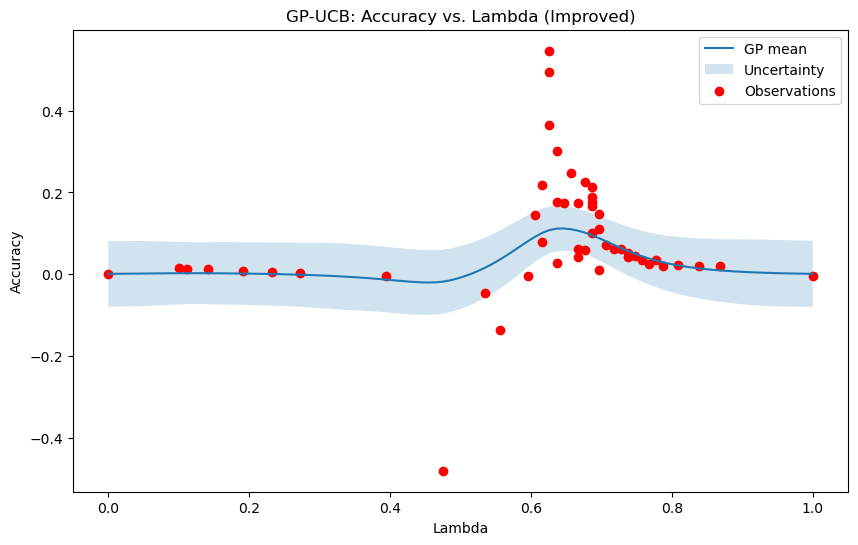

In [4]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
import matplotlib.pyplot as plt

class KernelizedUCB:
    def __init__(self, lambda_range=[0, 1], gamma=0.9, alpha=2.0, kernel=None):
        self.lambda_range = lambda_range
        self.gamma = gamma  # Forgetting factor
        self.alpha = alpha  # Base exploration weight
        self.X = np.array([])
        self.y = np.array([])
        self.t = 0
        
        # More flexible kernel: Matern (nu=1.5) + wider bounds
        if kernel is None:
            self.kernel = ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * \
                          Matern(length_scale=0.1, length_scale_bounds=(1e-2, 1e2), nu=1.5)
        else:
            self.kernel = kernel
        
        self.gp = GaussianProcessRegressor(kernel=self.kernel, alpha=0.1, n_restarts_optimizer=5)

    def update(self, lambda_, accuracy):
        """Update the GP with new data and apply forgetting."""
        lambda_ = np.array(lambda_).reshape(-1, 1)
        accuracy = np.array(accuracy).reshape(-1, 1)
        
        if self.t == 0:
            self.X = lambda_
            self.y = accuracy
        else:
            self.X = np.vstack((self.X, lambda_))
            self.y = np.vstack((self.y, accuracy))
            
            # Exponential forgetting
            if self.gamma < 1.0:
                self.y[:-1] *= self.gamma
        
        self.t += 1
        self.gp.fit(self.X, self.y)

    def predict(self, lambda_):
        """Predict mean and stddev for a lambda."""
        lambda_ = np.array(lambda_).reshape(-1, 1)
        mu, sigma = self.gp.predict(lambda_, return_std=True)
        return mu, sigma

    def choose_lambda(self, n_candidates=100):
        """Select next lambda via UCB with adaptive exploration."""
        candidates = np.linspace(self.lambda_range[0], self.lambda_range[1], n_candidates).reshape(-1, 1)
        mu, sigma = self.predict(candidates)
        
        # Adaptive exploration: scale alpha with uncertainty
        ucb = mu.flatten() + self.alpha * np.sqrt(np.log(self.t + 1)) * sigma
        
        best_idx = np.argmax(ucb)
        best_lambda = candidates[best_idx][0]
        return best_lambda

    def plot(self):
        """Plot the GP mean and uncertainty."""
        test_lambdas = np.linspace(self.lambda_range[0], self.lambda_range[1], 100).reshape(-1, 1)
        mu, sigma = self.predict(test_lambdas)
        
        plt.figure(figsize=(10, 6))
        plt.plot(test_lambdas, mu, label="GP mean")
        plt.fill_between(
            test_lambdas.flatten(),
            mu.flatten() - sigma,
            mu.flatten() + sigma,
            alpha=0.2,
            label="Uncertainty"
        )
        plt.scatter(self.X, self.y, c="red", label="Observations")
        plt.xlabel("Lambda")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.title("GP-UCB: Accuracy vs. Lambda (Improved)")
        plt.show()

# Example usage
if __name__ == "__main__":
    # Initialize with adaptive settings
    kucb = KernelizedUCB(gamma=0.9, alpha=2.0)
    
    # Simulate a non-stationary accuracy function
    def true_accuracy(lambda_, t):
        return np.sin(10 * lambda_) + 0.1 * np.random.randn() + 0.01 * t
    
    # Run optimization
    for t in range(50):
        lambda_ = kucb.choose_lambda()
        accuracy = true_accuracy(lambda_, t)
        kucb.update(lambda_, accuracy)
        print(f"Step {t}: lambda = {lambda_:.3f}, accuracy = {accuracy:.3f}")
    
    kucb.plot()

In [6]:
import numpy as np

# Generate 10 log-spaced values between 10^0 = 1 and 10^1 = 10
log_values = np.logspace(0, 1, num=6)

# Normalize to [0, 1] range
log_ticks_01 = (log_values - log_values.min()) / (log_values.max() - log_values.min())

# Print the values
print(log_ticks_01)


[0.         0.06498813 0.16798738 0.33123019 0.5899526  1.        ]


In [7]:
log_ticks_01

array([0.        , 0.06498813, 0.16798738, 0.33123019, 0.5899526 ,
       1.        ])